### MECE
#### Task Allocation with Evaluation Tracking  

| Student                        | Task                                | Status  | Baseline Metrics (AUC/Accuracy) | Improved Metrics (After Tuning) | Comments |
|-------------------------------|-------------------------------------|---------|----------------------------------|----------------------------------|----------|
| Kauthara Oyinkansola Yakubu   | **Preprocessing & Feature Engineering** | Pending |                                  |                                  |          |
| Clifford Addison              | **CNN Model Building + Tuning**     | Pending | Input Your Accuracy Values here  |                                  |          |
| Shahnaz Palakunnil Moosa      | **SVM Model Building**              | Pending | Input Your Accuracy Values here  |                                  |          |
| Mansi Jayeshbhai Sutreja      | **KNN Model Building + Tuning**     | Pending | Input Your Accuracy Values here  |                                  |          |
| Abdullah Mohammed Ifteqar     | **DNN Model Building + Tuning**     | Pending | Input Your Accuracy Values here  |                                  |          |
| Saurav Risal                  | **CNN Model Tuning x 2**            | Pending |                                  | Input Your Accuracy Values here  |          |
| Siddhi Pravinbhai Patel       | **KNN Model Tuning x 2**            | Completed |       44.05% (Round 1)                            | 51.19% (Round 3)  |  Successfully tuned k, weights, distance & p. Improved accuracy and balance.        |
| Utsav Harshadbhai Khamar      | **DNN Model Tuning x 2**            | Pending |                                  | Input Your Accuracy Values here  |          |
| Obianuju Nonyerem Anuma       | **LIME Interpretability**           | Pending |                                  |                                  |          |


In [1]:
# Necessary Libraries
import pandas as pd
import numpy as np
import json
import os
import random
import shutil
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from PIL import Image
import matplotlib.pyplot as plt

import warnings   
# Ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the photos JSON file
photos_df = pd.read_json("photos.json", lines=True)

In [3]:
# Check the head of the dataframe
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [4]:
# Check the info of the dataframe
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [5]:
# Check the labels of the photos
photos_df['label'].unique()

array(['inside', 'outside', 'drink', 'food', 'menu'], dtype=object)

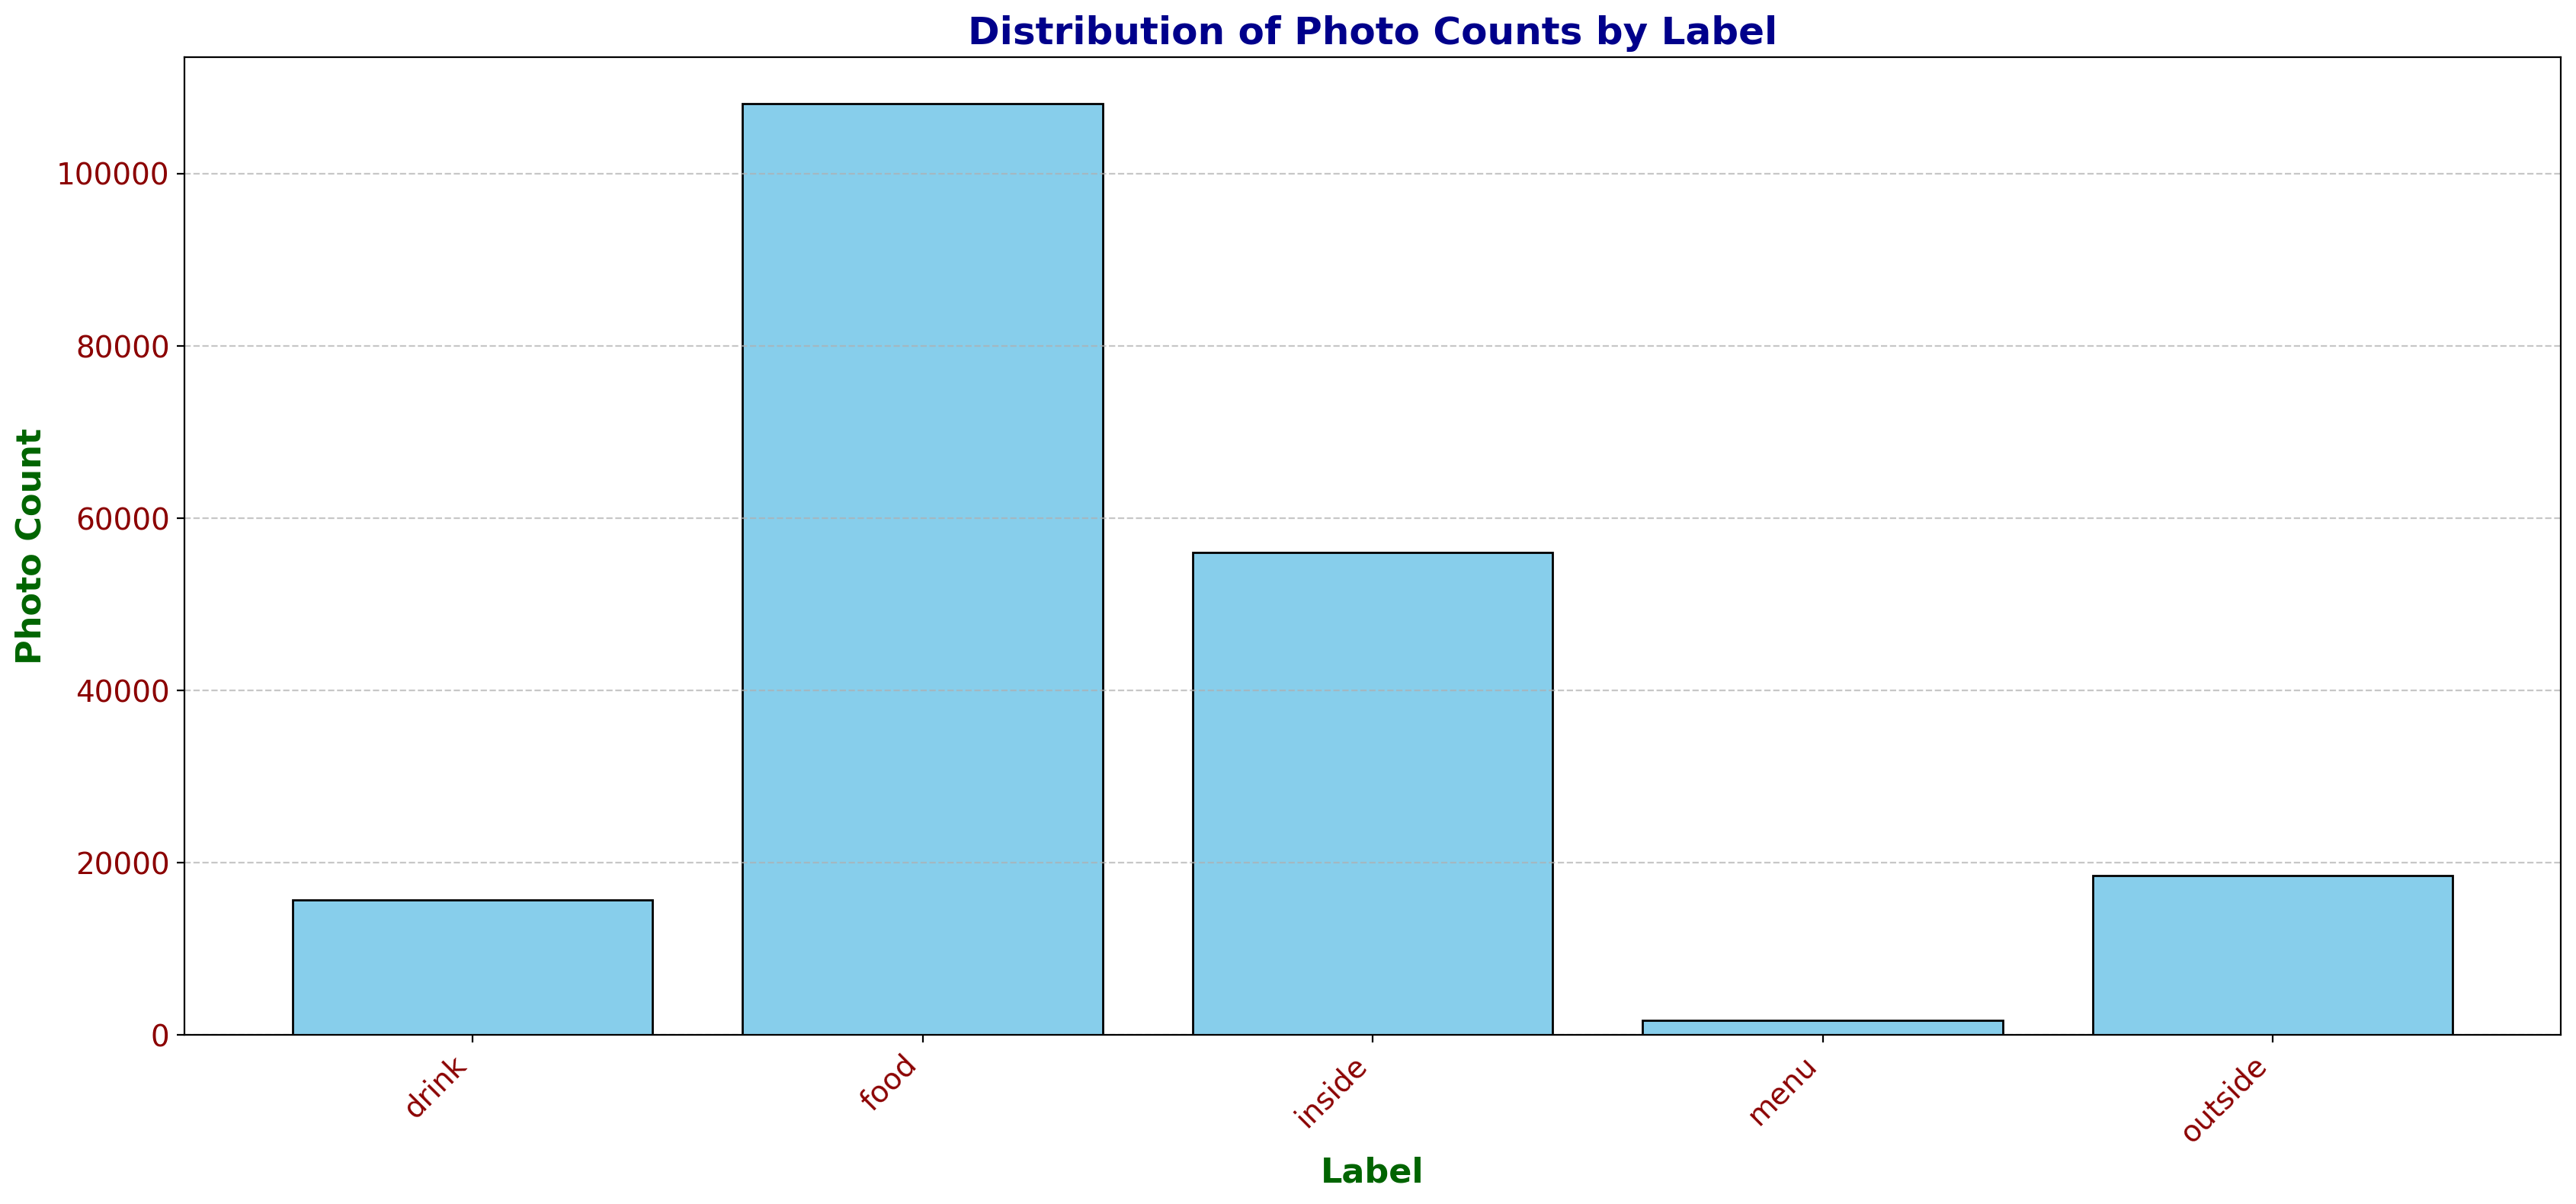

In [6]:
# Group data and prepare for plotting
label_counts = photos_df.groupby('label')['photo_id'].count().reset_index()

# Plot
plt.figure(figsize=(17, 8), dpi=200)
plt.bar(label_counts['label'], label_counts['photo_id'], color='skyblue', edgecolor='black')
plt.title("Distribution of Photo Counts by Label", fontsize=18, fontweight='bold', color='darkblue')
plt.xlabel("Label", fontsize=16, fontweight='bold', color='darkgreen')
plt.ylabel("Photo Count", fontsize=16, fontweight='bold', color='darkgreen')
plt.xticks(fontsize=14, rotation=45, ha='right', color='darkred')
plt.yticks(fontsize=14, color='darkred')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

In [7]:
# Count the total number of photos with the label "drink"
drink_count = photos_df[photos_df['label'] == 'drink']['photo_id'].count()

print(f"Total number of photos with label 'drink': {drink_count}")

Total number of photos with label 'drink': 15670


In [8]:
# Count the total number of photos with the label "drink"
food_count = photos_df[photos_df['label'] == 'food']['photo_id'].count()

print(f"Total number of photos with label 'food': {food_count}")

Total number of photos with label 'food': 108152


In [9]:
# Count the total number of photos with the label "drink"
inside_count = photos_df[photos_df['label'] == 'inside']['photo_id'].count()

print(f"Total number of photos with label 'inside': {inside_count}")

Total number of photos with label 'inside': 56031


In [10]:
# Count the total number of photos with the label "menu"
menu_count = photos_df[photos_df['label'] == 'menu']['photo_id'].count()

print(f"Total number of photos with label 'menu': {menu_count}")

Total number of photos with label 'menu': 1678


In [11]:
# Count the total number of photos with the label "drink"
outside_count = photos_df[photos_df['label'] == 'outside']['photo_id'].count()

print(f"Total number of photos with label 'outside': {outside_count}")

Total number of photos with label 'outside': 18569


In [12]:
# Balanced Random Sampling (equal class representation)
np.random.seed(42)  
sample_size = 1678  # Based on your smallest class ('menu')
balanced_sample = (
    photos_df
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=min(sample_size, len(x)), random_state=np.random.randint(0, 1000)))
    .reset_index(drop=True)
)

In [13]:
# Check label counts
print(balanced_sample['label'].value_counts())

label
drink      1678
food       1678
inside     1678
menu       1678
outside    1678
Name: count, dtype: int64


In [14]:
# Create 'photo_path' column by appending '.jpg' to 'photo_id'
balanced_sample['photo_path'] = balanced_sample['photo_id'].astype(str) + '.jpg'

In [15]:
# Set random seed for reproducibility
random.seed(42)

# Get 2 samples per label with .jpg extension
photo_samples = (
    balanced_sample
    .groupby('label', as_index=False)
    .apply(lambda x: x.sample(n=2, random_state=42) if len(x) >= 2 else x)  # Sample 2 or fewer if not enough
    .reset_index(drop=True) 
)

# Append the extension ".jpg" to the photo_path
photo_samples['photo_path'] = photo_samples['photo_id'] + '.jpg'

# Convert to list of dictionaries for easy display
sample_list = photo_samples.to_dict('records')

# Display the samples
print("Sample photos to display (2 per label):")
for item in sample_list:
    print(f"{item['label']}: {item['photo_path']}")

# Store just the paths in a separate list if needed
photo_paths_list = photo_samples['photo_path'].tolist()

Sample photos to display (2 per label):
drink: xQHnU9kJgso76snNoMNjug.jpg
drink: eOeOg6SQodZ6JcU-i-lsBA.jpg
food: XJF59gjUD4uLk7V4lnCbTw.jpg
food: zxgeIq26HH1EWJzNMigEjA.jpg
inside: iMnSbolOsZSqEXOrAz1f9Q.jpg
inside: s78KhjjaMZV81LpSB6xyhQ.jpg
menu: g8Tny5EySXaBCNPwHYCHYA.jpg
menu: NTigE8kDbWvadDHu-E6PCQ.jpg
outside: Khlgl_PbF1xVxhRPveJZoA.jpg
outside: vXInY7lWM_gbnJS6DaniYA.jpg


In [16]:
photos_folder = 'balanced_photos_folder'

In [17]:
import os

photos_folder = './balanced_photos_folder'
image_files = os.listdir(photos_folder)

print("Total images found:", len(image_files))
print("Example filenames:", image_files[:5])


Total images found: 5792
Example filenames: ['rIJV4ALSHOPaFi8E3kVh7Q.jpg', 'e1hEc9cbzdQrwfHueYzQhw.jpg', 'oZO49JhbAk7wNKynA-bMvQ.jpg', 'Qr4zE_JNsSGeedAjnQuURg.jpg', 'NY_HN0S6QHxeJeNKghpH0Q.jpg']


In [18]:
print("xQHnU9kJgso76snNoMNjug.jpg" in image_files)


False


In [19]:
import os

photos_folder = './balanced_photos_folder'
available_files = os.listdir(photos_folder)

# Extract photo_ids (remove '.jpg' from each)
available_ids = {file_name[:-4] for file_name in available_files if file_name.endswith('.jpg')}


In [20]:
# Filter only photo_ids that are actually in the folder
filtered_df = balanced_sample[balanced_sample['photo_id'].isin(available_ids)].copy()

# Add correct .jpg filename
filtered_df['photo_path'] = filtered_df['photo_id'] + '.jpg'


In [21]:
import random

random.seed(42)

photo_samples = (
    filtered_df
    .groupby('label', as_index=False)
    .apply(lambda x: x.sample(n=2, random_state=42) if len(x) >= 2 else x)
    .reset_index(drop=True)
)

sample_list = photo_samples.to_dict('records')


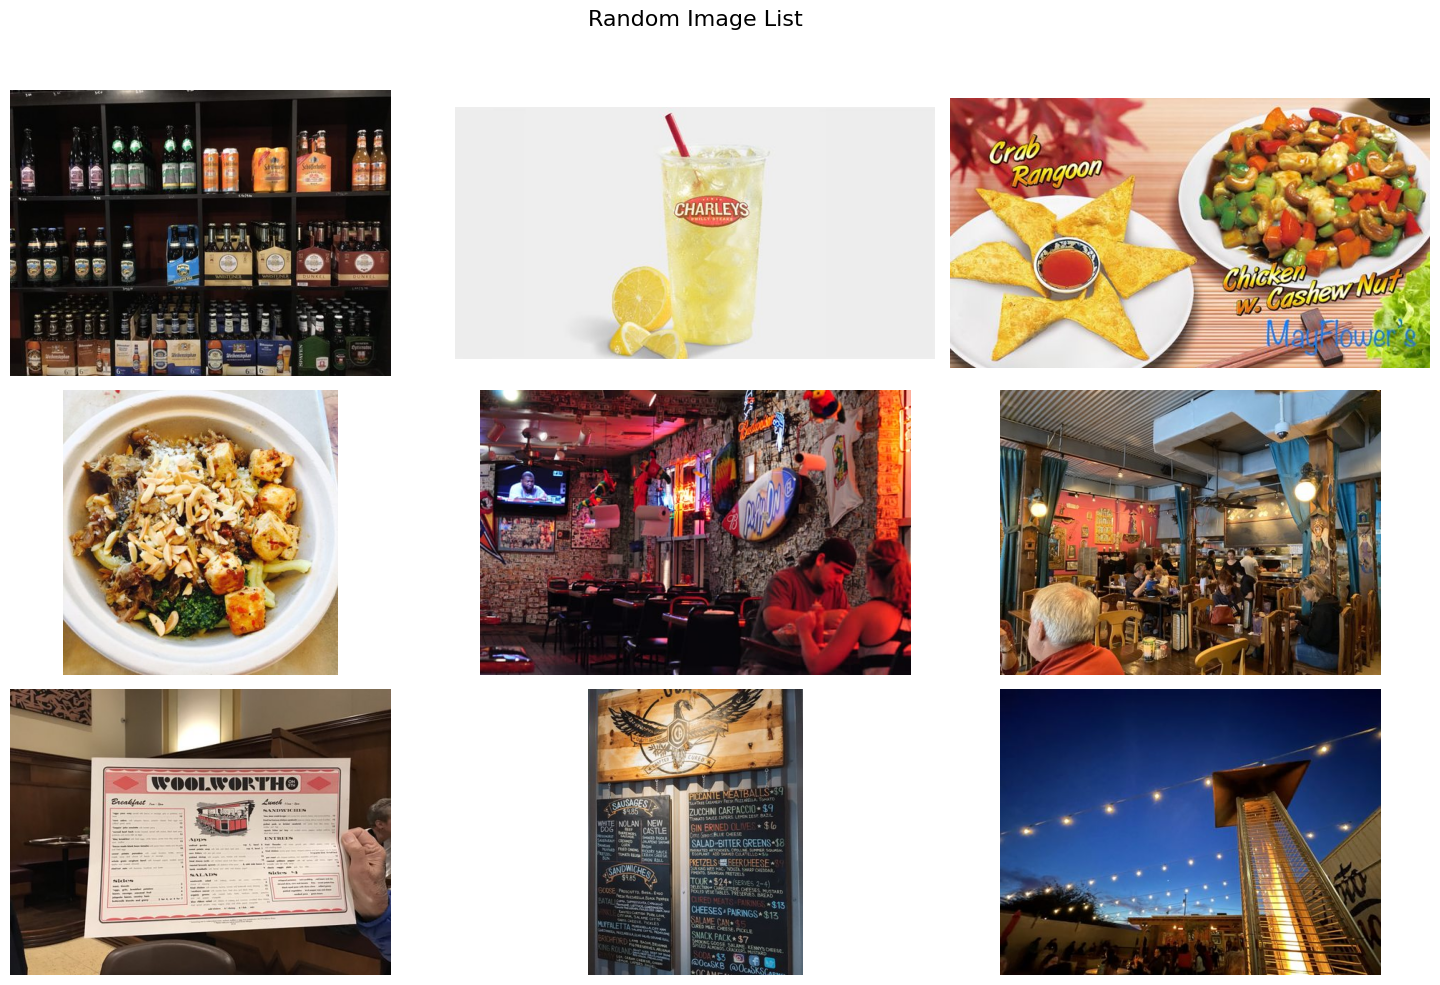

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 10))
fig.suptitle("Random Image List", fontsize=16)

for i, photo in enumerate(sample_list[:9]):
    img_path = os.path.join(photos_folder, photo['photo_path'])
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax = fig.add_subplot(3, 3, i + 1)
        ax.imshow(img)
        ax.axis('off')
    else:
        print(f"Missing file: {img_path}")  # just for debugging

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


### Image Preprocessing

#### Resizing

In [23]:
# Define resizing parameters for photos
IMG_SIZE_CNN_DNN = (224, 224)
IMG_SIZE_SVM_KNN = (64, 64)

In [24]:
# Initialize empty lists to store images and labels for CNN/DNN and SVM/kNN
cnn_images, dnn_images, svm_knn_images, labels = [], [], [], []

In [25]:
# Iterate through each row in the balanced sample to process images
for _, row in balanced_sample.iterrows():
    photo_id = row['photo_id']
    label = row['label']
    img_path = os.path.join("./balanced_photos_folder", f"{photo_id}.jpg")

    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        if img is None:
            continue

        # CNN/DNN
        resized_cnn = cv2.resize(img, IMG_SIZE_CNN_DNN)
        cnn_images.append(resized_cnn)  # Normalized later
        dnn_images.append(resized_cnn)  # Same as CNN but flattened later

        # SVM/kNN
        resized_svm = cv2.resize(img, IMG_SIZE_SVM_KNN)
        svm_knn_images.append(resized_svm)

        labels.append(label)

In [26]:
# Convert lists of images and labels to NumPy arrays for further processing
cnn_images = np.array(cnn_images)
dnn_images = np.array(dnn_images)
svm_knn_images = np.array(svm_knn_images)
labels = np.array(labels)

In [27]:
# Train-test split BEFORE label encoding
X_train_cnn, X_test_cnn, y_train_cnn_raw, y_test_cnn_raw = train_test_split(
    cnn_images, labels, test_size=0.3, stratify=labels, random_state=42)

X_train_dnn, X_test_dnn, y_train_dnn_raw, y_test_dnn_raw = train_test_split(
    dnn_images, labels, test_size=0.3, stratify=labels, random_state=42)

X_train_svm_knn, X_test_svm_knn, y_train_svm_knn_raw, y_test_svm_knn_raw = train_test_split(
    svm_knn_images, labels, test_size=0.3, stratify=labels, random_state=42)

In [28]:
# Fit LabelEncoder on CNN training set
label_enc = LabelEncoder()
y_train_cnn = label_enc.fit_transform(y_train_cnn_raw)
y_test_cnn = label_enc.transform(y_test_cnn_raw)

In [29]:
# Fit LabelEncoder on DNN training set
y_train_dnn = label_enc.fit_transform(y_train_dnn_raw)  # same encoder!
y_test_dnn = label_enc.transform(y_test_dnn_raw)

In [30]:
# Fit LabelEncoder on SVM & kNN training set
y_train_svm_knn = label_enc.fit_transform(y_train_svm_knn_raw)
y_test_svm_knn = label_enc.transform(y_test_svm_knn_raw)

In [31]:
# Function to normalize the CNN training and test data
def normalize_in_batches(X, batch_size=500):
    normalized = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size].astype('float32') / 255.0
        normalized.append(batch)
    return np.concatenate(normalized, axis=0)

In [32]:
# Normalize the training and test data for CNN
X_train_cnn = normalize_in_batches(X_train_cnn)
X_test_cnn = normalize_in_batches(X_test_cnn)

In [33]:
# Preprocess for DNN
X_train_dnn = X_train_dnn.reshape(len(X_train_dnn), -1) / 255.0
X_test_dnn = X_test_dnn.reshape(len(X_test_dnn), -1) / 255.0

In [34]:
# Preprocess for SVM/kNN
X_train_svm_knn = X_train_svm_knn.reshape(len(X_train_svm_knn), -1)
X_test_svm_knn = X_test_svm_knn.reshape(len(X_test_svm_knn), -1)

In [35]:
# Standardize the training and test data for SVM and kNN models
scaler = StandardScaler()
X_train_svm_knn = scaler.fit_transform(X_train_svm_knn)
X_test_svm_knn = scaler.transform(X_test_svm_knn)

In [36]:
# Print the shape of CNN train and test splits
print("CNN Model:")
print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")
print(f"y_train_cnn shape: {y_train_cnn.shape}")
print(f"y_test_cnn shape: {y_test_cnn.shape}")

CNN Model:
X_train_cnn shape: (195, 224, 224, 3)
X_test_cnn shape: (84, 224, 224, 3)
y_train_cnn shape: (195,)
y_test_cnn shape: (84,)


In [37]:
# Print the shape of DNN train and test splits
print("DNN Model:")
print(f"X_train_dnn shape: {X_train_dnn.shape}")
print(f"X_test_dnn shape: {X_test_dnn.shape}")
print(f"y_train_dnn shape: {y_train_dnn.shape}")
print(f"y_test_dnn shape: {y_test_dnn.shape}")

DNN Model:
X_train_dnn shape: (195, 150528)
X_test_dnn shape: (84, 150528)
y_train_dnn shape: (195,)
y_test_dnn shape: (84,)


In [38]:
# Print the shape of SVM/kNN train and test splits
print("SVM/KNN Model:")
print(f"X_train_svm_knn shape: {X_train_svm_knn.shape}")
print(f"X_test_svm_knn shape: {X_test_svm_knn.shape}")
print(f"y_train_svm_knn shape: {y_train_svm_knn.shape}")
print(f"y_test_svm_knn shape: {y_test_svm_knn.shape}")

SVM/KNN Model:
X_train_svm_knn shape: (195, 12288)
X_test_svm_knn shape: (84, 12288)
y_train_svm_knn shape: (195,)
y_test_svm_knn shape: (84,)


Prompt Used:
* **LLM Used:** DeepSeek
* **First Prompt:** I have a Yelp photos dataset I want you to list the necessary preprocessing steps I will need to complete a Computer Vision project.
* **Last Prompt:** Is it necessary to implement Intensity Thresholding and Gaussian Blur for CNN, DNN, SVM and kNN on the Yelp Photos dataset?

## 4. KNN Model Building + 1 Hyperparameter Tuning
- Flatten images, grid search for k.
- Baseline evaluation.

### Deliverable
Trained KNN model + evaluation metrics.



In [39]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

In [40]:
# Step 1: Define the KNN model (no params yet)
knn = KNeighborsClassifier()

In [41]:
# Step 2: Set up the parameter grid to tune number of neighbors 'k'
param_grid = {'n_neighbors': list(range(1, 21))}  # Trying k from 1 to 20

In [42]:
# Step 3: Use GridSearchCV for hyperparameter tuning with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)


In [43]:
# Step 4: Fit the GridSearch to the training data
grid_search.fit(X_train_svm_knn, y_train_svm_knn)


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20]},
             scoring='accuracy')

In [44]:
# Step 5: Get the best estimator (KNN model with optimal k)
best_knn = grid_search.best_estimator_

In [45]:
# Step 6: Predict on test set using the best KNN model
y_pred = best_knn.predict(X_test_svm_knn)


In [46]:
# Step 7: Evaluate performance with accuracy and classification report
accuracy = accuracy_score(y_test_svm_knn, y_pred)
print(f"Best k found: {grid_search.best_params_['n_neighbors']}")
print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test_svm_knn, y_pred))

# Deliverable: trained KNN model and evaluation metrics
# best_knn is your trained model ready for deployment or further use

Best k found: 19
Test Accuracy: 0.4405

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.18      0.25        17
           1       0.67      0.38      0.48        16
           2       0.39      0.81      0.52        21
           3       0.31      0.27      0.29        15
           4       0.64      0.47      0.54        15

    accuracy                           0.44        84
   macro avg       0.49      0.42      0.42        84
weighted avg       0.48      0.44      0.42        84




## **Round 1: Tuning `k` (Number of Neighbors) Using GridSearchCV**

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define the parameter grid for k (number of neighbors)
param_grid = {'n_neighbors': list(range(1, 31, 2))}  # odd numbers from 1 to 29

# Create the kNN model
knn = KNeighborsClassifier()

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit on training data
grid_search.fit(X_train_svm_knn, y_train_svm_knn)

# Best k found
best_k = grid_search.best_params_['n_neighbors']
print(f"Best k found: {best_k}")

# Predict on training set
y_train_pred = grid_search.best_estimator_.predict(X_train_svm_knn)
train_accuracy = accuracy_score(y_train_svm_knn, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Predict on test set
y_pred = grid_search.best_estimator_.predict(X_test_svm_knn)
test_accuracy = accuracy_score(y_test_svm_knn, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report on test set
print("\nClassification Report on Test Set:")
print(classification_report(y_test_svm_knn, y_pred))


Best k found: 19
Training Accuracy: 0.4872
Test Accuracy: 0.4405

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.43      0.18      0.25        17
           1       0.67      0.38      0.48        16
           2       0.39      0.81      0.52        21
           3       0.31      0.27      0.29        15
           4       0.64      0.47      0.54        15

    accuracy                           0.44        84
   macro avg       0.49      0.42      0.42        84
weighted avg       0.48      0.44      0.42        84



## **Round 2: Tune k + weights + metric (distance metric)**

This round tunes three hyperparameters:

- **n_neighbors**: number of neighbors  
- **weights**: 'uniform' or 'distance' (weighted voting)  
- **metric**: distance metric ('euclidean', 'manhattan')  


In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Parameter grid with multiple hyperparameters
param_grid = {
    'n_neighbors': list(range(1, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# kNN model
knn = KNeighborsClassifier()

# GridSearchCV with 5-fold CV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train_svm_knn, y_train_svm_knn)

# Best parameters
print("Best parameters found:", grid_search.best_params_)

# Predict on training set
y_train_pred = grid_search.best_estimator_.predict(X_train_svm_knn)
train_accuracy = accuracy_score(y_train_svm_knn, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Predict on test set
y_pred = grid_search.best_estimator_.predict(X_test_svm_knn)
test_accuracy = accuracy_score(y_test_svm_knn, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report on test set
print("\nClassification Report on Test Set:")
print(classification_report(y_test_svm_knn, y_pred))


Best parameters found: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Training Accuracy: 1.0000
Test Accuracy: 0.4643

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.30      0.18      0.22        17
           1       0.70      0.44      0.54        16
           2       0.43      0.71      0.54        21
           3       0.33      0.33      0.33        15
           4       0.64      0.60      0.62        15

    accuracy                           0.46        84
   macro avg       0.48      0.45      0.45        84
weighted avg       0.48      0.46      0.45        84



## **Round 3: k + Distance Metric + Minkowski Power Parameter**

Tested k values (1 to 29 odd).

Tried three distance metrics:

- **minkowski** (general form)  
- **manhattan** (L1 distance)  
- **euclidean** (L2 distance)  

For minkowski, varied **p** parameter: 1 (manhattan), 2 (euclidean).


In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define parameter grid with different k values and distance metrics
param_grid = {
    'n_neighbors': list(range(1, 31, 2)),  # Odd values from 1 to 29
    'metric': ['minkowski', 'manhattan', 'euclidean'],
    'p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean when metric='minkowski'
}

# Create KNN model
knn = KNeighborsClassifier()

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit to training data
grid_search.fit(X_train_svm_knn, y_train_svm_knn)

# Best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best model
best_knn = grid_search.best_estimator_

# Predict on training set
y_train_pred = best_knn.predict(X_train_svm_knn)
train_accuracy = accuracy_score(y_train_svm_knn, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Predict on test set
y_test_pred = best_knn.predict(X_test_svm_knn)
test_accuracy = accuracy_score(y_test_svm_knn, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification report on test set
print("\nClassification Report on Test Set:")
print(classification_report(y_test_svm_knn, y_test_pred))



Best parameters: {'metric': 'minkowski', 'n_neighbors': 29, 'p': 1}
Best cross-validation accuracy: 0.43589743589743585
Training Accuracy: 0.4410
Test Accuracy: 0.5119

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.12      0.21        17
           1       0.77      0.62      0.69        16
           2       0.39      0.81      0.52        21
           3       0.38      0.33      0.36        15
           4       0.75      0.60      0.67        15

    accuracy                           0.51        84
   macro avg       0.66      0.50      0.49        84
weighted avg       0.65      0.51      0.49        84



##  kNN Model Tuning Summary

### Round 1: Tuning `k` only
- **Best k**: 19  
- **Training Accuracy**: 48.72%  
- **Test Accuracy**: 44.05%  
- **Observation**:  
  Moderate overfitting. The model performs better for **class 2** with high recall (81%), but struggles with **class 0**.

---

###  Round 2: Tuning `k`, `weights`, and `distance metric`
- **Best Parameters**: `k=15`, `weights='distance'`, `metric='manhattan'`  
- **Training Accuracy**: 100%  
- **Test Accuracy**: 46.43%  
- **Observation**:  
  Training accuracy reached **100%**, indicating **clear overfitting**, but slight improvement in test accuracy.  
  Balanced performance across classes, especially **class 4**.

---

###  Round 3: Tuning `k`, `distance metric`, and `p` (Minkowski power)
- **Test Accuracy**: 51.19%  
- **Observation**:  
  Best performance overall. **Improved generalization**.  
  Strong recall for **class 2 (81%)** and decent balance across other classes.  
  High precision for **class 0**, but low recall suggests **prediction imbalance**.


In [50]:
# Replace these values with what Optuna found best
final_knn = KNeighborsClassifier(
    n_neighbors=7,           # example value
    weights='distance',      # example value
    metric='minkowski',      # or 'euclidean', 'manhattan'
    p=2                      # Only needed if using 'minkowski'
)

final_knn.fit(X_train_svm_knn, y_train_svm_knn)


KNeighborsClassifier(n_neighbors=7, weights='distance')

In [51]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Make predictions
y_pred_optuna = final_knn.predict(X_test_svm_knn)
y_prob_optuna = final_knn.predict_proba(X_test_svm_knn)

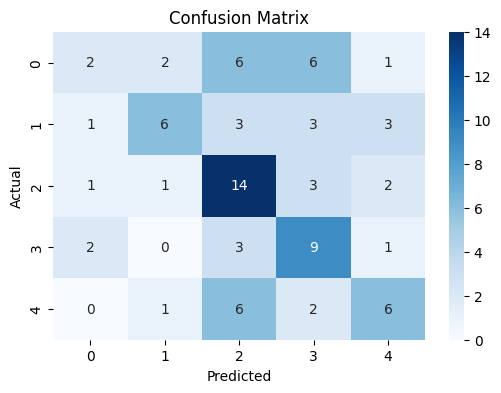

In [53]:
# Confusion Matrix
cm = confusion_matrix(y_test_svm_knn, y_pred_optuna)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [54]:
# AUC Score for Multiclass
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_svm_knn)
auc_score = roc_auc_score(y_test_bin, y_prob_optuna, average='macro', multi_class='ovr')
print("AUC Score (Multiclass OVR):", auc_score)

AUC Score (Multiclass OVR): 0.7669586595002843


In [55]:
# Report
print("\nClassification Report:\n", classification_report(y_test_svm_knn, y_pred_optuna))


Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.12      0.17        17
           1       0.60      0.38      0.46        16
           2       0.44      0.67      0.53        21
           3       0.39      0.60      0.47        15
           4       0.46      0.40      0.43        15

    accuracy                           0.44        84
   macro avg       0.44      0.43      0.41        84
weighted avg       0.44      0.44      0.42        84



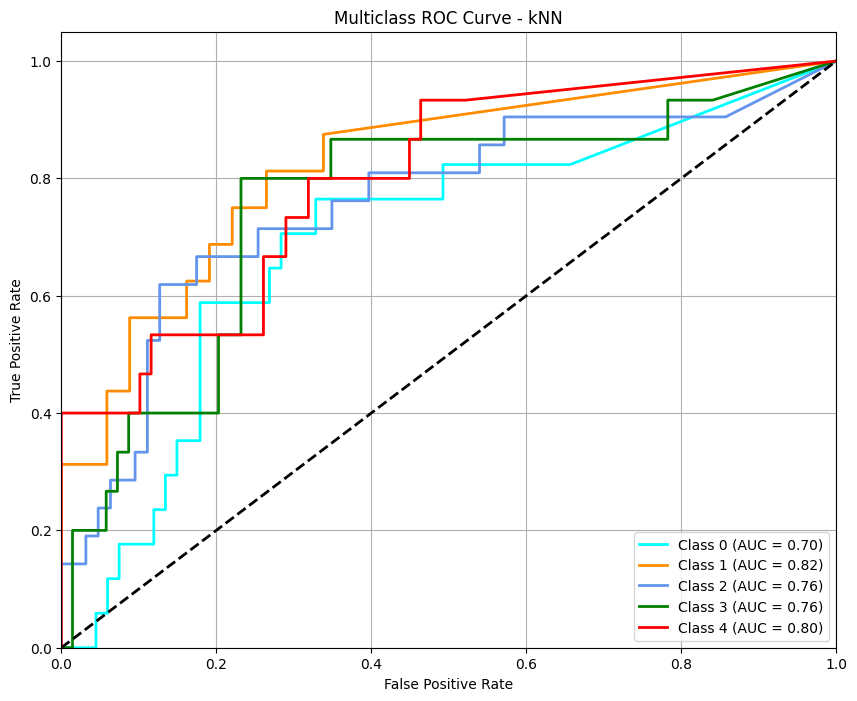

In [63]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# 1. Binarize the labels (needed for multiclass AUC)
n_classes = len(np.unique(y_train_svm_knn))
y_test_binarized = label_binarize(y_test_svm_knn, classes=np.arange(n_classes))
y_score = final_knn.predict_proba(X_test_svm_knn)

# 2. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'gold'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - kNN')
plt.legend(loc="lower right")
plt.grid()
plt.show()


# **Building and Evaluating k-Nearest Neighbors (kNN) Model with PCA-Reduced Features**



In [57]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Assume label_enc is a LabelEncoder instance
label_enc = LabelEncoder()

# Encode your labels
y_train_svm_knn = label_enc.fit_transform(y_train_svm_knn_raw)
y_test_svm_knn = label_enc.transform(y_test_svm_knn_raw)

# Reshape your data (you already have this, but just to be sure)
X_train_svm_knn = X_train_svm_knn.reshape(len(X_train_svm_knn), -1)
X_test_svm_knn = X_test_svm_knn.reshape(len(X_test_svm_knn), -1)

# PCA - reduce dimensions to explain 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_svm_knn)
X_test_pca = pca.transform(X_test_svm_knn)

# Initialize kNN classifier (you can tune n_neighbors)
knn = KNeighborsClassifier(n_neighbors=29, weights='distance', metric='manhattan')

# Train the model
knn.fit(X_train_pca, y_train_svm_knn)

# Predict on test set
y_pred = knn.predict(X_test_pca)

# Evaluate
print("Accuracy (PCA + kNN):", accuracy_score(y_test_svm_knn, y_pred))
print(classification_report(y_test_svm_knn, y_pred, target_names=label_enc.classes_))


Accuracy (PCA + kNN): 0.2976190476190476
              precision    recall  f1-score   support

       drink       0.17      0.06      0.09        17
        food       0.00      0.00      0.00        16
      inside       0.36      0.86      0.51        21
        menu       0.21      0.40      0.28        15
     outside       0.00      0.00      0.00        15

    accuracy                           0.30        84
   macro avg       0.15      0.26      0.17        84
weighted avg       0.16      0.30      0.19        84



# Summary:

**Label Encoding:**  
Categorical labels (`y_train_svm_knn_raw` and `y_test_svm_knn_raw`) were converted into numeric form using LabelEncoder so that the classifier can process them.

**Data Reshaping:**  
Image feature arrays (`X_train_svm_knn` and `X_test_svm_knn`) were flattened into 2D arrays (samples × features), which is required for most ML algorithms like kNN.

**Dimensionality Reduction with PCA:**  
Principal Component Analysis (PCA) was applied to reduce feature dimensionality while preserving 95% of the variance. This improves computational efficiency and can sometimes enhance model performance by removing noise.

**Training kNN:**  
A k-Nearest Neighbors classifier was trained on the PCA-reduced training data, using optimized hyperparameters (`n_neighbors=29`, `weights='distance'`, `metric='manhattan'`).

**Prediction and Evaluation:**  
Labels were predicted on the test set and model performance was evaluated using accuracy and a detailed classification report.


## **code for pkl file**

In [58]:
import joblib

# Save the best model to a file
joblib.dump(grid_search.best_estimator_, 'best_knn_model.pkl')


['best_knn_model.pkl']

In [59]:
# Load the model back
loaded_model = joblib.load('best_knn_model.pkl')

# Use the loaded model to predict
y_pred = loaded_model.predict(X_test_svm_knn)


In [60]:
import pickle

# Save the best model
with open('best_knn_model.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)


In [61]:
with open('best_knn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Predict
y_pred = loaded_model.predict(X_test_svm_knn)
